In [30]:
#import tidy all data csv file
import os
import pandas as pd

tidy_all_data = pd.read_csv(os.path.join('..','..','data','processed','tidy_all_metrics.csv'))



In [31]:
# clustering municipalities based on PCA of selected metrics

# --- PCA + clustering pipeline (add / run in a new cell) ---
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mstats

# choose baseline year and metric list (edit to taste)
BASE_YEAR = 2021


features_to_use = [
    # Context
    'Remoteness', 
    'Log_Population', #redundant with remoteness
    'Latitude', 
    'Longitude',
    'Climate_Action_Plan',
    
    # Wellbeing baseline
    'Income', 'Education', 'Housing', 'Labour_Force', #'CWB',
    
    # Wellbeing trajectories
    'income_percent_change', 'education_percent_change', 
    'housing_percent_change', 'labour_percent_change', 
    'population_percent_change',
    
    # Low-emissions energy shares baseline
    'Utility_Residential_Electricity_Energy_Share', 
    'Utility_CSMI_Electricity_Energy_Share', #redundant with Utility_Residential_Electricity_Energy_Share
    'Transportation_Low_Emission_Vehicle_km_Travelled_Share', #redundant with remoteness
    
    # Economic structure baseline
    'Utility_CSMI_Total_Energy_Share', #this is share on total utility enery, not including tranport

    # Energy transition trajectories
    'Log_Residential_Electricity_Share_Change',
    'Log_Residential_Electricity_Level_Change',
    'Log_Residential_Polluting_Level_Change',
    'Log_CSMI_Electricity_Share_Change',
    'Log_CSMI_Electricity_Level_Change',
    'Log_CSMI_Polluting_Level_Change',
    'Log_Transport_Low_Emission_Share_Change', #redundant with remoteness and transportation low emissions vehicle km travelled share
    'Log_Transport_Low_Emission_Level_Change', 
    'Log_Transport_Polluting_Level_Change',
    
    # Economic transition trajectories
    'Log_CSMI_Total_Energy_Share_Change',
    
    # Per capita values
    'Log_Transportation_Polluting_Vehicle_km_Travelled_Per_Capita',
    'Log_Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita',
    'Log_Residential_Electricity_Per_Capita', #redundant with Utility_Residential_Electricity_Energy_Share
    'Log_Residential_Polluting_Per_Capita', # redundant with Utility_Residential_Electricity_Energy_Share
    'Log_CSMI_Electricity_Per_Capita',
    'Log_CSMI_Polluting_Per_Capita' #redundant with Utility_Residential_Electricity_Energy_Share and Utility_CSMI_Total_Energy_Share
    
    # Emissions factors baselinec-> potentially redundant as shares can capture this already
    #'Residential_Emissions_Factor',
    #'CSMI_Emissions_Factor',
    #'Transportation_Emissions_Factor',
    
    # Energy sources baseline (log-transformed)
    #'Log_Utility_Residential_Electricity_Energy',
    #'Log_Utility_Residential_Polluting_Energy',
    #'Log_Utility_CSMI_Electricity_Energy',
    #'Log_Utility_CSMI_Polluting_Energy', 
    #'Log_Transportation_Low_Emission_Vehicle_km_Travelled',
    #'Log_Transportation_Polluting_Vehicle_km_Travelled',
]
bimodal_features = [
    'Remoteness',
    'Income',
    'Education',
    'Housing',
    'Labour_Force',
    'labour_percent_change',
    'housing_percent_change',
    'Utility_Residential_Electricity_Energy_Share',
    'Log_CSMI_Polluting_Per_Capita',
    'Climate_Action_Plan' 
]


all_features = tidy_all_data['Metric'].unique().tolist()

# build wide feature matrix for BASE_YEAR
df_feat = tidy_all_data.loc[tidy_all_data['Year'] == BASE_YEAR, ['Municipality_Name','Metric','Value']].copy()
# Find duplicates
duplicates = df_feat[df_feat.duplicated(subset=['Municipality_Name', 'Metric'], keep=False)]
print(f"Found {len(duplicates)} duplicate rows:")
display(duplicates.sort_values(['Municipality_Name', 'Metric']))

df_wide = df_feat.pivot(index='Municipality_Name', columns='Metric', values='Value')

# ensure chosen features are present, add missing as NaN
for f in features_to_use:
    if f not in df_wide.columns:
        df_wide[f] = np.nan

# select only desired columns and drop rows with no data at all
X = df_wide[features_to_use].copy()

# diagnostic: find missing values BEFORE scaling/PCA (PCA/Scaler do not accept NaN)
nan_counts = X.isna().sum()
if nan_counts.sum() > 0:
    print("Missing values present. Counts per feature:\n", nan_counts[nan_counts > 0])
    nan_rows = X[X.isna().any(axis=1)]
    print("\nCommunities with missing data (total {}):".format(len(nan_rows)))
    for idx, row in nan_rows.iterrows():
        missing_feats = row[row.isna()].index.tolist()
        print(f" - {idx}: missing {missing_feats}")
    # show some raw tidy rows for the first few affected communities to investigate source
    sample_comm = list(nan_rows.index)[:8]
    print("\nSample raw tidy_all_data rows for inspection:")
    display(tidy_all_data[tidy_all_data['Municipality_Name'].isin(sample_comm)].sort_values(['Municipality_Name','Year','Metric']).head(40))
else:
    print("No missing values found in X.")


Found 0 duplicate rows:


,Municipality_Name,Metric,Value


No missing values found in X.


In [32]:

from diptest import diptest

bimodal_features = []
for col in X.columns:
    dip, p = diptest(X[col].values)
    if p < 0.1:
        bimodal_features.append(col)
        print(f"{col}: p={p:.4f} (bimodal)")

Remoteness: p=0.0003 (bimodal)
Climate_Action_Plan: p=0.0000 (bimodal)
Income: p=0.0068 (bimodal)
Education: p=0.0682 (bimodal)
Housing: p=0.0000 (bimodal)
Labour_Force: p=0.0001 (bimodal)
housing_percent_change: p=0.0000 (bimodal)
labour_percent_change: p=0.0000 (bimodal)
Utility_CSMI_Electricity_Energy_Share: p=0.0000 (bimodal)
Log_CSMI_Polluting_Per_Capita: p=0.0000 (bimodal)


In [33]:
# Correlation matrix
corr_matrix = X.corr().abs()

# Find pairs with correlation > 0.85
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print("Highly correlated pairs (keep one, drop other):")
for v1, v2, corr in high_corr_pairs:
    print(f"  {v1} <-> {v2}: {corr:.2f}")

Highly correlated pairs (keep one, drop other):
  Remoteness <-> Log_Population: 0.70
  Remoteness <-> Transportation_Low_Emission_Vehicle_km_Travelled_Share: 0.73
  Remoteness <-> Log_Transport_Low_Emission_Share_Change: 0.75
  Utility_Residential_Electricity_Energy_Share <-> Utility_CSMI_Electricity_Energy_Share: 0.70
  Utility_Residential_Electricity_Energy_Share <-> Log_Residential_Electricity_Per_Capita: 0.72
  Utility_Residential_Electricity_Energy_Share <-> Log_Residential_Polluting_Per_Capita: 0.92
  Utility_Residential_Electricity_Energy_Share <-> Log_CSMI_Polluting_Per_Capita: 0.70
  Utility_CSMI_Electricity_Energy_Share <-> Log_CSMI_Polluting_Per_Capita: 0.92
  Transportation_Low_Emission_Vehicle_km_Travelled_Share <-> Log_Transport_Low_Emission_Share_Change: 0.95
  Utility_CSMI_Total_Energy_Share <-> Log_CSMI_Polluting_Per_Capita: 0.79
  Log_Transport_Low_Emission_Share_Change <-> Log_Transport_Low_Emission_Level_Change: 0.76


In [34]:
from sklearn.metrics import silhouette_score

def evaluate_features(feature_list):
    X_subset = X[feature_list]
    X_scaled = StandardScaler().fit_transform(X_subset)
    pca = PCA(n_components=min(4, len(feature_list)))
    X_pca = pca.fit_transform(X_scaled)
    X_pca_std = StandardScaler().fit_transform(X_pca)
    
    km = KMeans(n_clusters=5, random_state=42, n_init=100)
    labels = km.fit_predict(X_pca_std)
    return silhouette_score(X_pca_std, labels)

# Baseline
baseline_score = evaluate_features(features_to_use)
print(f"Baseline silhouette: {baseline_score:.3f}")

# Try removing each feature
for feature in features_to_use:
    reduced = [f for f in bimodal_features if f != feature]
    score = evaluate_features(reduced)
    change = score - baseline_score
    print(f"Remove {feature}: {score:.3f} ({change:+.3f})")

Baseline silhouette: 0.259
Remove Remoteness: 0.234 (-0.025)
Remove Log_Population: 0.239 (-0.020)
Remove Latitude: 0.239 (-0.020)
Remove Longitude: 0.239 (-0.020)
Remove Climate_Action_Plan: 0.237 (-0.022)
Remove Income: 0.250 (-0.009)
Remove Education: 0.236 (-0.023)
Remove Housing: 0.239 (-0.020)
Remove Labour_Force: 0.225 (-0.034)
Remove income_percent_change: 0.239 (-0.020)
Remove education_percent_change: 0.239 (-0.020)
Remove housing_percent_change: 0.242 (-0.017)
Remove labour_percent_change: 0.248 (-0.011)
Remove population_percent_change: 0.239 (-0.020)
Remove Utility_Residential_Electricity_Energy_Share: 0.239 (-0.020)
Remove Utility_CSMI_Electricity_Energy_Share: 0.236 (-0.023)
Remove Transportation_Low_Emission_Vehicle_km_Travelled_Share: 0.239 (-0.020)
Remove Utility_CSMI_Total_Energy_Share: 0.239 (-0.020)
Remove Log_Residential_Electricity_Share_Change: 0.239 (-0.020)
Remove Log_Residential_Electricity_Level_Change: 0.239 (-0.020)
Remove Log_Residential_Polluting_Level_C

PCA reduced to 3 components to explain 80% variance
Silhouette scores by k: {3: np.float64(0.36664837426666247), 4: np.float64(0.2734314148633212), 5: np.float64(0.2983020255411662), 6: np.float64(0.313870181689025), 7: np.float64(0.3140262831393593), 8: np.float64(0.30386559475772), 9: np.float64(0.3199253560082682)}
Best k: 3 score: 0.36664837426666247


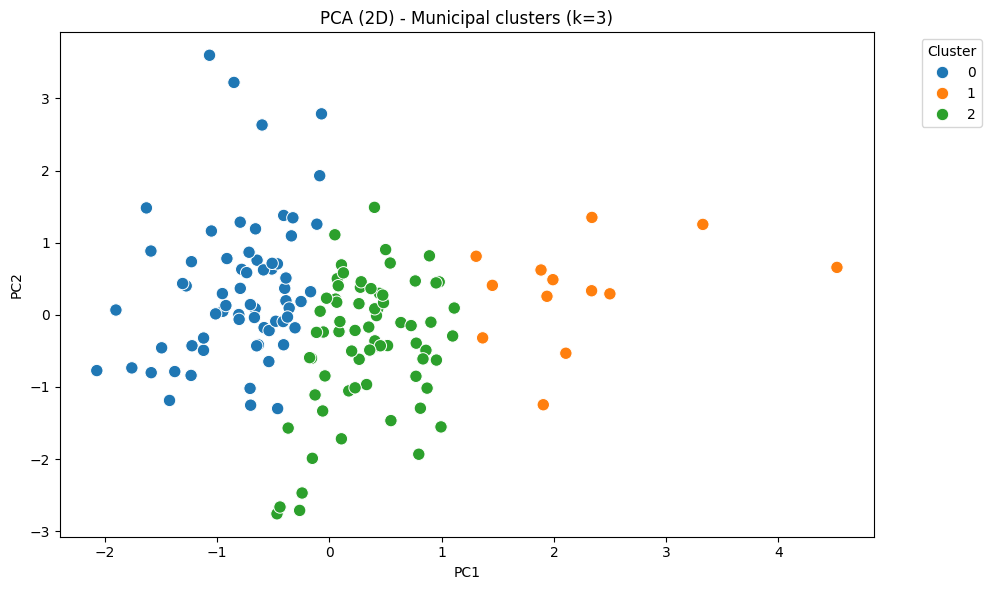

,Remoteness,Log_Population,Latitude,Longitude,Climate_Action_Plan,Income,Education,Housing,Labour_Force,income_percent_change,...,Log_Transport_Low_Emission_Share_Change,Log_Transport_Low_Emission_Level_Change,Log_Transport_Polluting_Level_Change,Log_CSMI_Total_Energy_Share_Change,Log_Transportation_Polluting_Vehicle_km_Travelled_Per_Capita,Log_Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita,Log_Residential_Electricity_Per_Capita,Log_Residential_Polluting_Per_Capita,Log_CSMI_Electricity_Per_Capita,Log_CSMI_Polluting_Per_Capita
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.42,3.34,51.87,-122.86,0.33,78.50,59.44,93.91,83.00,10.35,...,0.0,0.20,0.06,-0.01,4.09,2.11,1.33,1.32,1.33,1.13
1,0.26,4.10,49.47,-122.21,0.77,82.62,71.31,95.23,88.62,11.89,...,0.0,0.45,0.17,-0.00,3.97,2.16,1.37,1.04,1.24,0.81
2,0.21,4.23,49.53,-121.59,0.72,83.32,69.70,95.72,86.51,10.78,...,0.0,0.44,0.07,0.00,3.97,2.19,1.27,1.29,1.12,1.25


,Remoteness,Log_Population,Latitude,Longitude,Climate_Action_Plan,Income,Education,Housing,Labour_Force,income_percent_change,...,Log_Transport_Low_Emission_Share_Change,Log_Transport_Low_Emission_Level_Change,Log_Transport_Polluting_Level_Change,Log_CSMI_Total_Energy_Share_Change,Log_Transportation_Polluting_Vehicle_km_Travelled_Per_Capita,Log_Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita,Log_Residential_Electricity_Per_Capita,Log_Residential_Polluting_Per_Capita,Log_CSMI_Electricity_Per_Capita,Log_CSMI_Polluting_Per_Capita
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.12,0.50,2.43,4.24,0.48,4.10,5.01,2.62,4.43,4.70,...,0.0,0.20,0.08,0.04,0.14,0.17,0.12,0.27,0.31,0.87
1,0.12,0.76,0.69,3.36,0.44,3.15,3.77,1.92,2.43,3.98,...,0.0,0.20,0.12,0.02,0.05,0.07,0.18,0.47,0.33,0.63
2,0.12,0.64,1.19,2.73,0.45,5.68,6.40,1.37,2.19,3.19,...,0.0,0.16,0.12,0.02,0.16,0.14,0.11,0.24,0.28,0.65


In [35]:

        
# Standardize (use X for the pipeline)
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)
# ...continue with PCA/KMeans but remember to use X_for_clustering.index when assembling results
# ...existing code...

# PCA: keep components that explain 80% variance for clustering, but compute 2D for plotting
pca80 = PCA(n_components=0.80, svd_solver='full')
X_pca_80 = pca80.fit_transform(X)
X_pca_80_standardized = StandardScaler().fit_transform(X_pca_80)  # Equal weighting
print(f"PCA reduced to {X_pca_80.shape[1]} components to explain 80% variance")

#pca_4 = PCA(n_components=4)
#X_pca_4 = pca_4.fit_transform(X_scaled)
#X_pca_4_standardized = StandardScaler().fit_transform(X_pca_4)  # Equal weighting

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X)

# choose number of clusters with silhouette (k=2..8)
best_k, best_score = None, -1
scores = {}
for k in range(3, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=100)
    labels = km.fit_predict(X_pca_80)
    score = silhouette_score(X_pca_80, labels)
    scores[k] = score
    if score > best_score:
        best_score = score
        best_k = k

print("Silhouette scores by k:", scores)
print("Best k:", best_k, "score:", best_score)

# Fit final KMeans on PCA space
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=100)
labels_final = kmeans_final.fit_predict(X_pca_80)

# assemble results dataframe and save
clusters_df = pd.DataFrame({
    'Municipality_Name': X.index,
    'Cluster': labels_final
}).set_index('Municipality_Name')

# merge back some original features for inspection
clustered = X.merge(clusters_df, left_index=True, right_index=True)

# save CSV
clustered.reset_index().to_csv(os.path.join('..','..','data','processed','municipality_clusters_baseline2021.csv'), index=False)

# Plot PCA 2D scatter with cluster labels
plt.figure(figsize=(10,6))
palette = sns.color_palette('tab10', n_colors=best_k)
sns.scatterplot(x=X_pca_80_standardized[:,0], y=X_pca_80_standardized[:,1], hue=labels_final, palette=palette, s=80, legend='full')
plt.title(f'PCA (2D) - Municipal clusters (k={best_k})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

# Quick summary per cluster
display(clustered.groupby('Cluster').mean().round(2))
#save means in a csv
clustered.groupby('Cluster').mean().round(2).to_csv(os.path.join('..','..','data','processed','municipality_clusters_feature_means.csv'))

#display standard deviation per cluster
display(clustered.groupby('Cluster').std().round(2))
clustered.groupby('Cluster').std().round(2).to_csv(os.path.join('..','..','data','processed','municipality_clusters_feature_std.csv'))


In [36]:
municipality_names = X.index


/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_2407/1114871863.py:11: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



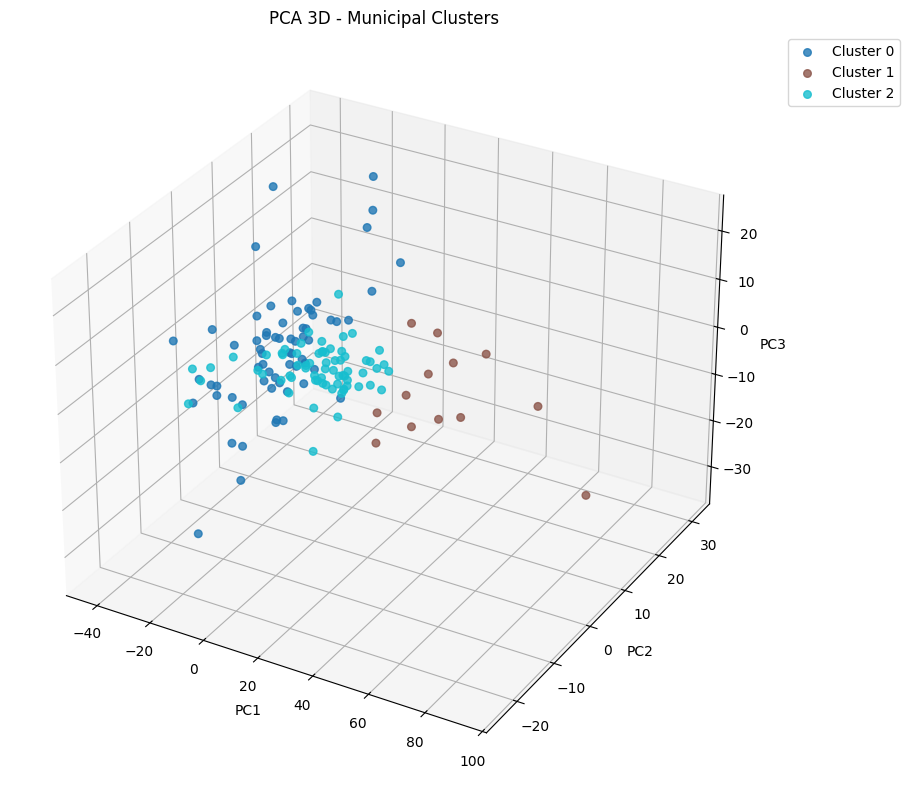

In [37]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import numpy as np
import pandas as pd

df3 = pd.DataFrame(X_pca3, columns=['PC1','PC2','PC3'], index=municipality_names)
df3['Cluster'] = labels_final

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
palette = plt.cm.get_cmap('tab10', np.unique(labels_final).size)

for k in np.unique(labels_final):
    mask = df3['Cluster'] == k
    ax.scatter(
        df3.loc[mask, 'PC1'],
        df3.loc[mask, 'PC2'],
        df3.loc[mask, 'PC3'],
        label=f'Cluster {k}',
        s=30,
        alpha=0.8,
        color=palette(k)
    )

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('PCA 3D - Municipal Clusters')
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.tight_layout()
#plt.savefig('reports/figures/pca_3d_clusters.png', dpi=200, bbox_inches='tight')
plt.show()

In [38]:
import plotly.express as px
import pandas as pd

# X_pca3: numpy array shape (n_samples, 3)
# labels_final: 1D array of cluster labels
# municipality_names: index or list of municipality names (length n_samples)
municipality_names = X.index
df3 = pd.DataFrame(X_pca3, columns=['PC1','PC2','PC3'], index=municipality_names)
df3['Cluster'] = labels_final
df3['Municipality'] = df3.index

fig = px.scatter_3d(
    df3,
    x='PC1', y='PC2', z='PC3',
    color='Cluster',
    hover_name='Municipality',
    symbol='Cluster',
    size_max=6,
    title='PCA 3D - Municipal Clusters',
    opacity=0.9
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(scene=dict(
    xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3'
))
fig.show()

# Optional: save interactive HTML
#fig.write_html('reports/figures/pca_3d_clusters.html', include_plotlyjs='cdn')

In [39]:
#calculate mean and std dev for all features of munis within each cluster, even the ones not used in clustering
# Pivot tidy_all_data to wide: municipalities × features
df_wide = tidy_all_data.pivot_table(
    index='Municipality_Name',
    columns='Metric',
    values='Value',
    aggfunc='first'  # in case of duplicates
)

# Add cluster labels (merge clusters_df into df_wide)
df_wide = df_wide.merge(clusters_df, left_index=True, right_index=True, how='left')

# Now compute stats per cluster
cluster_stats = df_wide.groupby('Cluster').agg(['mean', 'std'])
display(cluster_stats)

CWB           Climate_Action_Plan            Education  \
              mean       std                mean       std       mean   
Cluster                                                                 
0        75.606061  3.266985            0.333333  0.475017  53.621212   
1        80.384615  2.599310            0.769231  0.438529  61.846154   
2        80.275362  3.713584            0.724638  0.449969  62.985507   

                     Housing               Income            ...  \
              std       mean       std       mean       std  ...   
Cluster                                                      ...   
0        5.582294  92.848485  3.456287  71.242424  4.434344  ...   
1        5.145324  95.538462  2.066212  73.923077  3.839738  ...   
2        7.072093  95.797101  1.567873  75.347826  6.690261  ...   

        education_percent_change            housing_percent_change            \
                            mean        std                   mean       std   
Cluster                                                                        
0                      11.601329  10.776661               1.237492  3.653884   
1                      15.659253   6.357563              -0.295120  2.284184   
2                      10.943705   3.936763              -0.062010  1.464990   

        income_percent_change           labour_percent_change            \
                         mean       std                  mean       std   
Cluster                                                                   
0                   10.345460  4.696713             -1.943011  4.782015   
1                   11.888042  3.978641             -1.828374  3.218683   
2                   10.779769  3.190488             -0.601846  2.168621   

        population_percent_change             
                             mean        std  
Cluster                                       
0                       -0.882019   9.147211  
1                       58.682479  18.422050  
2                       19.950764   8.582560  

[3 rows x 186 columns]

In [40]:

# Quick diagnostics: which input variables drive PCs and clusters
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from scipy.stats import f_oneway
from IPython.display import display


X_df = X.copy()
Xs = X.copy()
labels = labels_final.copy()


# PCA loadings (full PCA on standardized inputs)
pca_full = PCA().fit(Xs)
loadings = pd.DataFrame(pca_full.components_.T,
                        index=X_df.columns,
                        columns=[f'PC{i+1}' for i in range(pca_full.components_.shape[0])])
explained = pd.Series(pca_full.explained_variance_ratio_, index=loadings.columns)

# Find variables with max absolute loading < 0.2 across PC1-PC4
max_loadings = loadings.iloc[:, :4].abs().max(axis=1)
low_contributors = max_loadings[max_loadings < 0.2].index.tolist()
print("Consider removing:", low_contributors)

print("Explained variance (first 6 PCs):")
print(explained.head(6).round(3))

print("\nTop contributors to PC1 (absolute loading):")
display(loadings['PC1'].abs().sort_values(ascending=False).head(10))

print("\nTop contributors to PC2 (absolute loading):")
display(loadings['PC2'].abs().sort_values(ascending=False).head(10))


Consider removing: ['Remoteness', 'Log_Population', 'Latitude', 'Longitude', 'Climate_Action_Plan', 'Housing', 'housing_percent_change', 'Utility_Residential_Electricity_Energy_Share', 'Utility_CSMI_Electricity_Energy_Share', 'Transportation_Low_Emission_Vehicle_km_Travelled_Share', 'Utility_CSMI_Total_Energy_Share', 'Log_Residential_Electricity_Share_Change', 'Log_Residential_Electricity_Level_Change', 'Log_Residential_Polluting_Level_Change', 'Log_CSMI_Electricity_Share_Change', 'Log_CSMI_Electricity_Level_Change', 'Log_CSMI_Polluting_Level_Change', 'Log_Transport_Low_Emission_Share_Change', 'Log_Transport_Low_Emission_Level_Change', 'Log_Transport_Polluting_Level_Change', 'Log_CSMI_Total_Energy_Share_Change', 'Log_Transportation_Polluting_Vehicle_km_Travelled_Per_Capita', 'Log_Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita', 'Log_Residential_Electricity_Per_Capita', 'Log_Residential_Polluting_Per_Capita', 'Log_CSMI_Electricity_Per_Capita', 'Log_CSMI_Polluting_Per_Capita

Metric
population_percent_change    0.968310
Education                    0.200529
Labour_Force                 0.085370
education_percent_change     0.062409
Income                       0.058645
Latitude                     0.051643
Longitude                    0.038521
Housing                      0.037659
income_percent_change        0.030240
housing_percent_change       0.024331
Name: PC1, dtype: float64


Top contributors to PC2 (absolute loading):


Metric
education_percent_change     0.677867
Education                    0.505442
Income                       0.448786
Labour_Force                 0.175345
income_percent_change        0.131900
Longitude                    0.108904
population_percent_change    0.101023
housing_percent_change       0.097466
Housing                      0.042991
labour_percent_change        0.026652
Name: PC2, dtype: float64

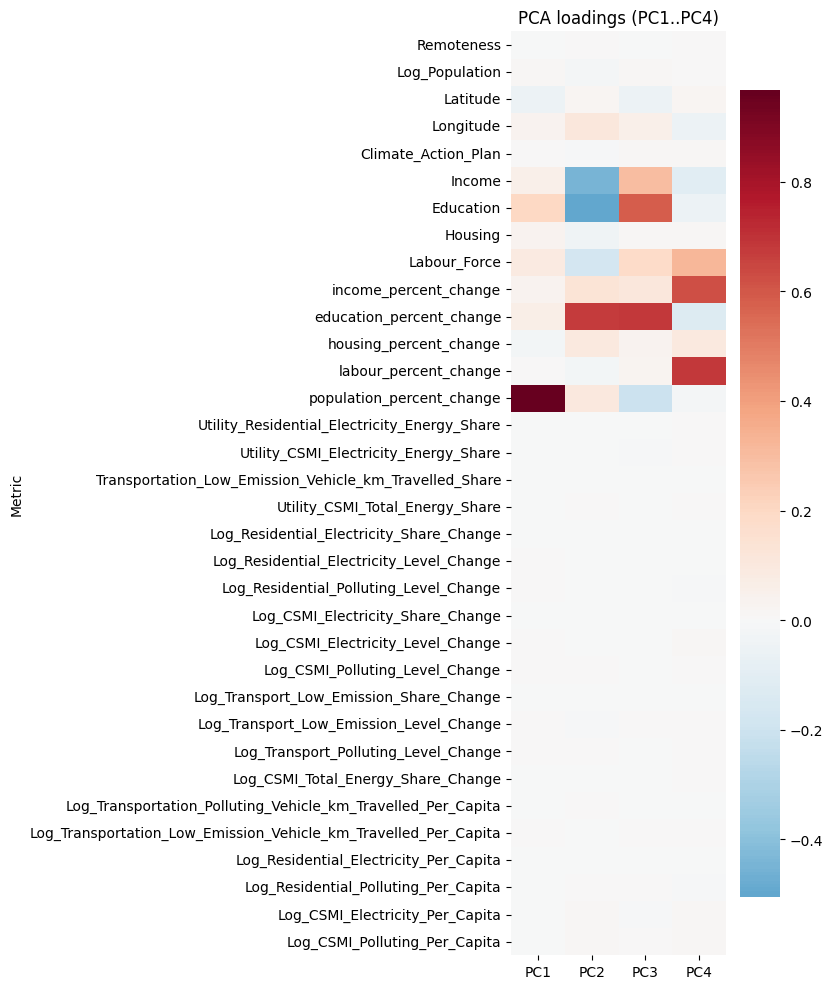


Top features by ANOVA F (difference across clusters):


,F,p
population_percent_change,214.778,0.0
Education,64.277,0.0
Remoteness,53.896,0.0
Log_Population,39.461,0.0
Log_Residential_Electricity_Level_Change,38.365,0.0
Transportation_Low_Emission_Vehicle_km_Travelled_Share,32.252,0.0
Log_Transport_Low_Emission_Share_Change,32.117,0.0
Log_Transport_Low_Emission_Level_Change,31.048,0.0
Latitude,30.116,0.0
Labour_Force,25.502,0.0



Top features by permutation importance (random forest predicting clusters):


Metric
population_percent_change                   0.0628
Remoteness                                  0.0000
Log_Transport_Low_Emission_Level_Change     0.0000
Log_Residential_Polluting_Level_Change      0.0000
Log_CSMI_Electricity_Share_Change           0.0000
Log_CSMI_Electricity_Level_Change           0.0000
Log_CSMI_Polluting_Level_Change             0.0000
Log_Transport_Low_Emission_Share_Change     0.0000
Log_Transport_Polluting_Level_Change        0.0000
Log_Residential_Electricity_Share_Change    0.0000
dtype: float64

/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_2407/3918062248.py:37: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



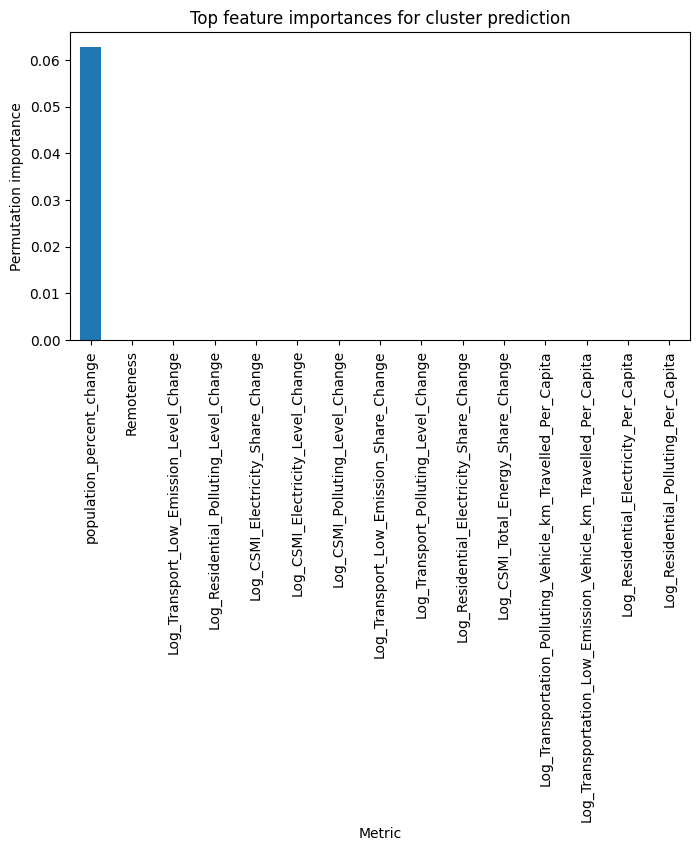


Interpretation hints:
- PCA loadings: large absolute loading = strong contributor to that PC.
- Explained variance: which PCs capture most variance.
- Cluster centroids: show how clusters differ on original features.
- ANOVA F: features with large F differ most across clusters (statistical).
- Permutation RF importance: features that best predict cluster membership (useful for interpretability).


In [41]:

# Heatmap of loadings for first 4 PCs
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,10))
sns.heatmap(loadings.iloc[:, :4], cmap='RdBu_r', center=0, annot=False)
plt.title('PCA loadings (PC1..PC4)')
plt.tight_layout()
plt.show()


# Which features differ most across clusters? ANOVA F-statistic
f_stats = {}
for col in X_df.columns:
    groups = [X_df[col].values[labels == k] for k in np.unique(labels)]
    try:
        f, p = f_oneway(*groups)
    except Exception:
        f, p = np.nan, np.nan
    f_stats[col] = (f, p)
f_df = pd.DataFrame.from_dict(f_stats, orient='index', columns=['F', 'p']).sort_values('F', ascending=False)
print("\nTop features by ANOVA F (difference across clusters):")
display(f_df.head(10).round(3))

# Supervised check: how predictive each feature is of the cluster (permutation importance)
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
X_filled = X_df.fillna(X_df.median())
rf.fit(X_filled, labels)
perm = permutation_importance(rf, X_filled, labels, n_repeats=30, random_state=42, n_jobs=-1)
imp_df = pd.Series(perm.importances_mean, index=X_df.columns).sort_values(ascending=False)
print("\nTop features by permutation importance (random forest predicting clusters):")
display(imp_df.head(10).round(4))

plt.figure(figsize=(8,4))
imp_df.head(15).plot.bar()
plt.ylabel('Permutation importance')
plt.title('Top feature importances for cluster prediction')
plt.tight_layout()
plt.show()

# Guidance:
print("\nInterpretation hints:")
print("- PCA loadings: large absolute loading = strong contributor to that PC.")
print("- Explained variance: which PCs capture most variance.")
print("- Cluster centroids: show how clusters differ on original features.")
print("- ANOVA F: features with large F differ most across clusters (statistical).")
print("- Permutation RF importance: features that best predict cluster membership (useful for interpretability).")


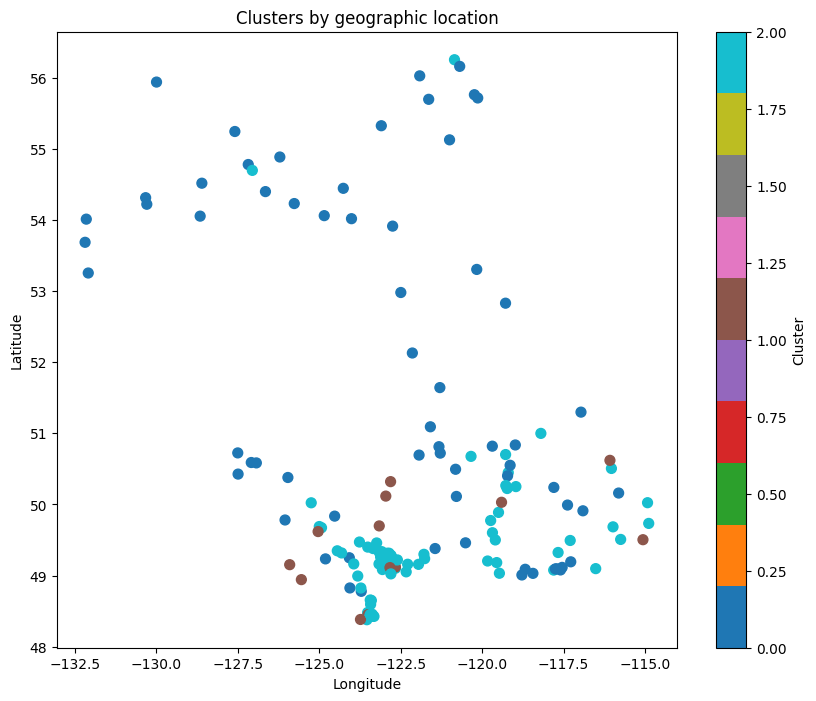

In [42]:
# Plot clusters on a map
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(clustered['Longitude'], clustered['Latitude'], c=clustered['Cluster'], cmap='tab10', s=50)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Clusters by geographic location')
plt.colorbar(label='Cluster')
plt.show()